# LLaVA-1.5 hallucination traversal

Companion to the paper's §*Attractors for traversals / hallucinations*. Qualitative single-image demo with LLaVA-1.5-7B: cache the mean image-token activation at a middle attention layer, then inject a scaled copy of it on every generation step to "remind" the model of the image and suppress hallucinated content as `strength` grows.

## Setup

In [1]:
import requests
from PIL import Image

from rich import print as pprint

import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration
import os
import matplotlib.pyplot as plt 

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Model

In [3]:
model_id = "llava-hf/llava-1.5-7b-hf"
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
).to(device)

processor = AutoProcessor.from_pretrained(model_id)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Image

Fetch one COCO sample over HTTP.

In [4]:
conversation = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Describe the image in detail."},
            {"type": "image"},
        ],
    },
]
prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)

image_file = "http://images.cocodataset.org/val2017/000000336232.jpg"
raw_image = Image.open(requests.get(image_file, stream=True).raw)
inputs = processor(images=raw_image, text=prompt, return_tensors='pt').to(device, torch.float16)


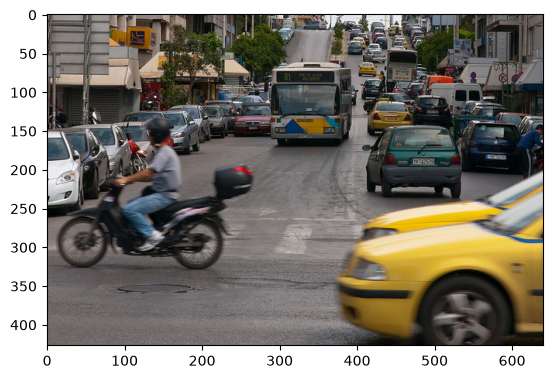

In [5]:
plt.imshow(raw_image)
plt.show()

## Baseline caption

Caption the image before any steering intervention.

In [6]:
output = model.generate(**inputs, max_new_tokens=512, do_sample=True)
pprint(processor.decode(output[0][2:], skip_special_tokens=True))


ER:  
Describe the image in detail. ASSISTANT: The image depicts a hilly city street filled with traffic. There are 
numerous cars, a few motorcycles, and a bus moving across the roadway. In the scene, there are 14 cars, 2 buses, 
and 5 motorcycles on the street, including one prominently placed motorcycle towards the bottom of the image.

Additionally, there are three people visible in the scene, with one person in the middle of the image, another 
person standing closer to the left-hand side, and the third person standing near the right-hand side of the image. 
They may be pedestrians or individuals involved in the traffic. It is a busy and hectic urban environment, with all
sorts of vehicles trying to navigate the hill-covered street.

## Attractor intervention

Register a forward hook on `self_attn` of one middle decoder layer. On the prefill pass (multi-token input) the hook caches the mean-pooled image-token activation into `concept`. On every subsequent single-token generation step it adds `strength * concept` to the attention output — "reminding" the model of the image and suppressing the drift that produces hallucinated content.

In [7]:
target_layer = 20

In [8]:
concept = None

def remind_image(target_layer):
    global concept
    def hook(model, input, output):
        global concept
        if (output[0].shape[1] != 1):
            concept = torch.mean(output[0], dim=1)
        else:
            output = (output[0] + strength*concept, *output[1:])
        return output
    return hook


hook = model.language_model.layers[target_layer].self_attn.register_forward_hook(remind_image(target_layer))

## Steered sweep

Regenerate while sweeping `strength`. At 0 you recover the baseline; as strength grows the caption stays more grounded in what's actually in the image.

In [9]:
for strength in [0, 3, 6, 9, 11]:
    print(strength)
    output = model.generate(**inputs, max_new_tokens=512, do_sample=True, top_k=None, top_p=1, temperature=1)
    pprint(processor.decode(output[0][2:], skip_special_tokens=True))


0


ER:  
Describe the image in detail. ASSISTANT: The image displays a busy city street filled with numerous cars, buses, 
and other vehicles backed up in traffic. There are several people standing and walking on the sidewalk, interacting
with the bustling environment. 

In the midst of the traffic, there are multiple cars in various positions, including a yellow taxi standing 
prominently at the bottom left corner. One car and a motorcycle can also be seen farther back on the scene.

Various buses are visible in the mix, with one large bus situated closer to the center, another a bit farther back,
and a third that spans from the middle to the upper area of the scene. The traffic creates a captivating urban 
panorama.

3


ER:  
Describe the image in detail. ASSISTANT: The image features an extraordinarily busy street in a metropolitan area, 
filled with traffic and nicely dressed people. A yellow taxi filled with people is speeding down the street, and 
there are several other cars and buses scattered along the road.

Traffic lights can be seen at various points throughout the scene. Pedestrians are present, actively navigating the
bustling city environment.

The various elements of the street include cars, buses, motorcycles, a truck, and a person with a helmet, possibly 
a motorcyclist or someone wearing a bicycle lane sticker on their surge jacket. All these elements together create 
a lively, high-activity atmosphere that makes the city seem thriving and dynamic.

6


ER:  
Describe the image in detail. ASSISTANT: The scene shows a crowded city street filled with several cars in various 
impactful angles, making the area appear very dynamic. A motorcyclist in white riding on the right lane of the busy
city street stands out, with their ability to move through the congested traffic.

People are visible throughout the area, walking on the sidewalks and navigating the busy streets. This bustling 
urban scene is likely to be in the gulf region or another busy street filled with traffic.

9


ER:  
Describe the image in detail. ASSISTANT: The image captures a busy yellow street filled with traffic and busy 
traffic on an uphill street. There is a mix of cars, buses, trucks, and motorcycles all navigating the busy road. 
Two well-sized buses can be seen in the middle of the image, while numerous smaller vehicles are either moving or 
waiting.

There is a person on a motorcycle, positioned towards the left side of the road near the front. A few cars are also
spewing out exhaust, further congesting the street. Traffic is going up and down hill, and the street is packed 
with traffic.

11


ER:  
Describe the image in detail. ASSISTANT: The image is a hill street bustling with traffic. Many cars and 
motorcycles are crowding the roads, creating a congested ride. A bus is driving down the hill on one side of the 
street, and another bus is parked on the sideway. Numerous vehicles are parked along the street and hanging onto 
the single one way street, causing the traffic to be unbearable.
t

The scene is filled with people - some walking next to the road or driving cars, motorcycles, and buses. They are 
also carrying backpacks, and in some instances, standing or sitting. The vibrant businesses seen on the street 
might be contributing to the traffic congestion, as many cars occupy the lane. Due to the sheer amount of vehicles,
the street is occupied, causing people to wait for their respective vehicles.